# Green Coffee Bean Classification — USK-COFFEE

Sorting green Arabica coffee beans into four grades: **defect, longberry, peaberry, premium**.

This is the model-building half of the MLOps pipeline. It covers data prep, a MobileNetV2
transfer-learning model, evaluation on a held-out test set, a single-image prediction function,
and a retraining routine that reuses the trained model as its own starting point. The saved
`.keras` file gets dropped into the deployment API afterwards.

Dataset: USK-Coffee (Febriana et al., 2022) — 8,000 images, 256×256, evenly balanced across the
four classes. Coffee is one of Rwanda's biggest exports, so the idea is a tool a cooperative could
point at a bean and get an instant grade instead of sorting by eye.

## Setup

Running on Colab with a T4 GPU. Quick check that the GPU is actually on
(Runtime → Change runtime type → T4 GPU), then mount Drive and unzip the dataset.

In [1]:
import tensorflow as tf
print("TF version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPU:", gpus if gpus else "none found — switch the runtime to T4 or this will crawl")

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount("/content/drive")

# I keep the zip in Drive and unpack it into the local session — reads are much faster
# off local disk than off the mounted Drive.
import zipfile, os
zip_path = "/content/drive/MyDrive/usk_coffee_dataset.zip"
with zipfile.ZipFile(zip_path) as z:
    z.extractall("/content")

DATA_DIR = "/content/usk_coffee_dataset/data"
print("train/test folders:", os.listdir(DATA_DIR))

# (Not on Colab? Just set DATA_DIR to wherever you unzipped it and skip the two cells above.)

Mounted at /content/drive
train/test folders: ['train', 'test', '{train,test}']


In [3]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
IMG_SIZE = (224, 224)   # MobileNetV2's native input size
BATCH = 32
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Loading the data

The folders are already split into `train/` and `test/`, one subfolder per class. I pull the
training images in with `image_dataset_from_directory` and hold back 15% as a validation set so I
can watch for overfitting while training. The test folder stays untouched until the very end.

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/train",
    validation_split=0.15,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/train",
    validation_split=0.15,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=False,          # keep order fixed so labels line up at eval time
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 6400 files belonging to 4 classes.
Using 5440 files for training.
Found 6400 files belonging to 4 classes.
Using 960 files for validation.
Found 1600 files belonging to 4 classes.
Classes: ['defect', 'longberry', 'peaberry', 'premium']


## A look at the data

Before training anything, worth understanding what's in here. Three things I want to know: are the
classes balanced, what do the beans actually look like, and do the classes differ in ways a model
can latch onto.

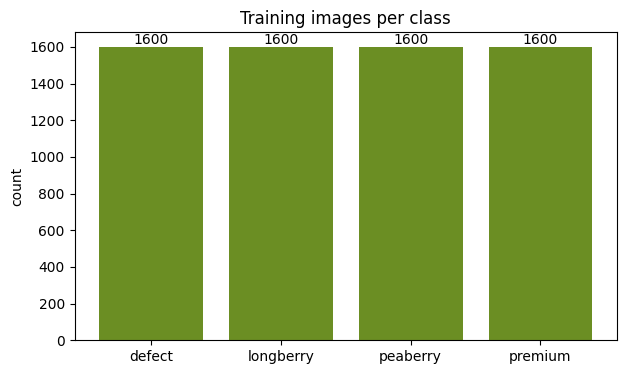

{'defect': 1600, 'longberry': 1600, 'peaberry': 1600, 'premium': 1600}

In [5]:
counts = {cls: len(list(Path(f"{DATA_DIR}/train/{cls}").glob("*.jpg"))) for cls in class_names}

plt.figure(figsize=(7, 4))
plt.bar(counts.keys(), counts.values(), color="#6b8e23")
plt.title("Training images per class")
plt.ylabel("count")
for i, v in enumerate(counts.values()):
    plt.text(i, v + 15, str(v), ha="center")
plt.show()
counts

**Read:** dead even — 1,600 per class. So no resampling or class weights needed, and plain accuracy
is a fair headline number since nothing is skewed. One less thing to worry about.

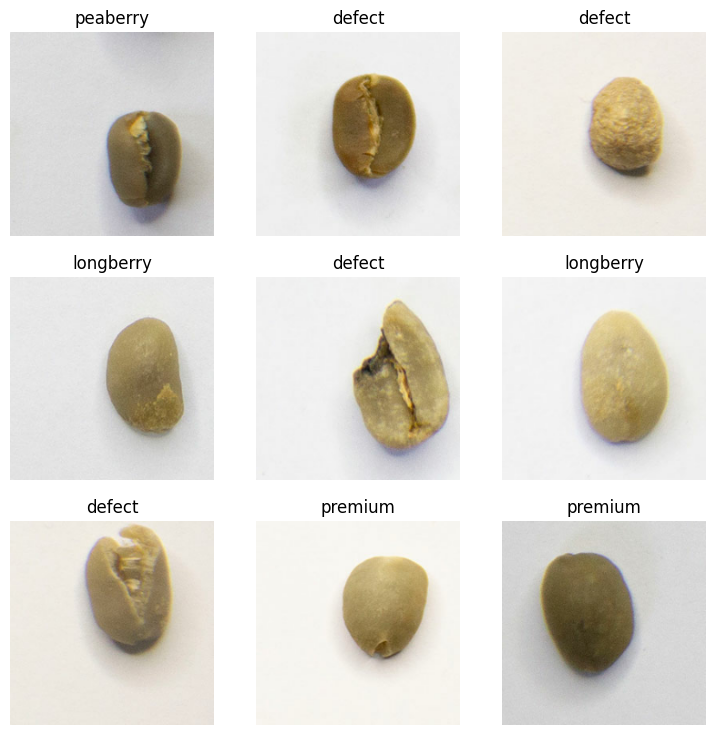

In [6]:
plt.figure(figsize=(9, 9))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

**Read:** clean shots — single bean, white background, consistent lighting. Good for the model
(no background clutter to learn around), but a reminder for deployment: predictions will only be
trustworthy on similar single-bean, plain-background photos. Longberry beans already look noticeably
elongated and peaberry rounder, so shape is doing work here, not just colour.

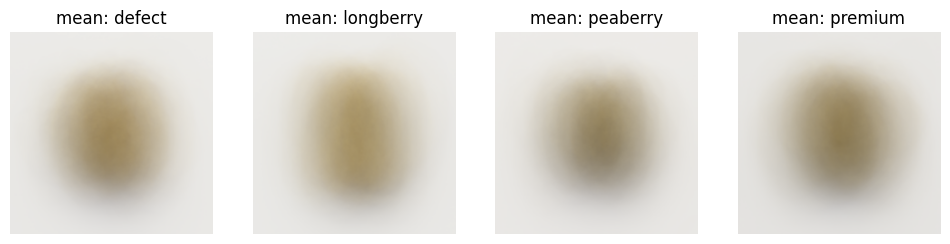

In [7]:
# Average ~200 beans per class. Individual detail blurs out and the "typical" silhouette is left.
def mean_image(cls, n=200):
    files = list(Path(f"{DATA_DIR}/train/{cls}").glob("*.jpg"))[:n]
    imgs = [tf.image.resize(tf.io.decode_jpeg(tf.io.read_file(str(f)), channels=3), IMG_SIZE)
            for f in files]
    return tf.reduce_mean(tf.stack(imgs), axis=0).numpy().astype("uint8")

plt.figure(figsize=(12, 4))
for i, cls in enumerate(class_names):
    plt.subplot(1, 4, i + 1)
    plt.imshow(mean_image(cls))
    plt.title(f"mean: {cls}")
    plt.axis("off")
plt.show()

**Read:** longberry's average is stretched vertically, peaberry's is a compact blob, premium sits in
between. Defect is the messiest average — defective beans vary a lot in shape and colour, so their
mean smears out. That already hints defect might be the hardest class to nail. Worth remembering when
we get to the confusion matrix.

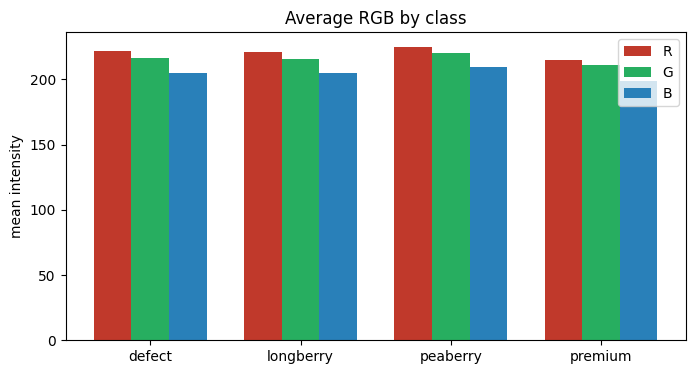

In [8]:
# Colour story: mean per-channel intensity on a random sample from each class.
def channel_means(cls, n=150):
    files = random.sample(list(Path(f"{DATA_DIR}/train/{cls}").glob("*.jpg")), n)
    arr = np.stack([tf.image.resize(tf.io.decode_jpeg(tf.io.read_file(str(f)), channels=3),
                                    IMG_SIZE).numpy() for f in files])
    return arr.reshape(-1, 3).mean(axis=0)

means = {c: channel_means(c) for c in class_names}
x = np.arange(len(class_names)); w = 0.25
plt.figure(figsize=(8, 4))
for j, (col, name) in enumerate(zip(["#c0392b", "#27ae60", "#2980b9"], ["R", "G", "B"])):
    plt.bar(x + (j - 1) * w, [means[c][j] for c in class_names], w, label=name, color=col)
plt.xticks(x, class_names); plt.ylabel("mean intensity"); plt.title("Average RGB by class")
plt.legend(); plt.show()

**Read:** careful here — this chart is measuring the *background*, not the beans. Every class lands
near 210 intensity because the white backdrop occupies most of the frame, and the small differences
that remain (premium marginally darkest, defect and peaberry nearly identical) say more about
lighting than about the beans.

Re-measured over the bean pixels only — masking out everything brighter than 200 — a real signal
appears: longberry is clearly the lightest class (mean brightness 137 against 124–129 for the rest)
and leads in all three channels, while **defect (124.9) and peaberry (124.5) are essentially
indistinguishable by colour**. So colour separates longberry well and cannot separate defect from
peaberry at all. Whatever tells those two apart has to be shape — which is exactly what the mean-image
plot above was showing. That masked version is what the deployment dashboard plots
(`scripts/build_insights.py`).

## Preprocessing and augmentation

Two things happen before an image hits the network. Augmentation — flips, small rotations, a little
zoom and contrast jitter — on the training set only, to push back on overfitting since the dataset
isn't huge. And MobileNetV2's own `preprocess_input`, which scales pixels to [-1, 1] the way the
pretrained weights expect. I put both inside the model graph so training, the notebook, and the API
all preprocess identically — nothing to forget or mismatch later.

In [9]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augment")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

## The model

Transfer learning with MobileNetV2. It's light — which matters once this gets Dockerized and
load-tested later in the pipeline — and ImageNet features transfer nicely to close-up object photos
like these. The base starts frozen; I only train a small head on top: global average pooling, a
dropout layer for regularisation, and a 4-way softmax.

In [10]:
base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = models.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Training — phase 1 (frozen base)

Early stopping watches validation loss and restores the best weights, and a `ModelCheckpoint` writes
the single best model (by validation accuracy) to disk as it goes. That checkpoint is the safety net
for the next phase — whatever fine-tuning does, the best model so far is already saved and can't be
lost. Gave it more epochs too, since the frozen phase was still climbing the first time I ran this.

In [11]:
import os
os.makedirs("models", exist_ok=True)
weights_path = "models/best.weights.h5"

callbacks = [
    ModelCheckpoint(weights_path, monitor="val_accuracy", mode="max",
                    save_best_only=True, save_weights_only=True),
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=callbacks)

Epoch 1/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 28s 102ms/step - accuracy: 0.5665 - loss: 1.0338 - val_accuracy: 0.7271 - val_loss: 0.7227 - learning_rate: 0.0010
Epoch 2/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.7031 - loss: 0.7369 - val_accuracy: 0.7490 - val_loss: 0.6448 - learning_rate: 0.0010
Epoch 3/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.7397 - loss: 0.6613 - val_accuracy: 0.7760 - val_loss: 0.6000 - learning_rate: 0.0010
Epoch 4/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.7684 - loss: 0.6053 - val_accuracy: 0.7802 - val_loss: 0.5846 - learning_rate: 0.0010
Epoch 5/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.7671 - loss: 0.5846 - val_accuracy: 0.7812 - val_loss: 0.5700 - learning_rate: 0.0010
Epoch 6/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.7844 - loss: 0.5588 - val_accuracy: 0.7896 - val_loss: 0.5539 - learning_rate: 0.0010
Epoch 7/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step - accuracy: 0.7812 - 

## Training — phase 2 (fine-tuning)

First time I ran this, fine-tuning actually *hurt* — the loss spiked and it ended up worse than the
frozen phase, and I kept the worse model by accident. Two fixes. One, start fine-tuning from the best
frozen weights (`load_weights`) instead of wherever phase 1 trailed off. Two, keep the BatchNorm
layers frozen even inside the unfrozen block — letting them update mid-fine-tune is what destabilises
transfer learning like this. And the checkpoint only overwrites the saved model if fine-tuning genuinely
beats phase 1 (`initial_value_threshold`), so this phase can only help, never set us back.

In [12]:
from tensorflow.keras.layers import BatchNormalization

# start fine-tuning from the BEST frozen weights, not wherever training happened to stop
model.load_weights(weights_path)
best_frozen = max(history.history["val_accuracy"])
print(f"best frozen val_accuracy so far: {best_frozen:.3f}")

base_model.trainable = True
for layer in base_model.layers[:-30]:              # only open the top ~30 layers
    layer.trainable = False
for layer in base_model.layers[-30:]:              # ...but keep BatchNorm frozen —
    if isinstance(layer, BatchNormalization):      # this is what stops the loss spiking
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# only overwrite the saved model if we actually beat the frozen phase's best
callbacks_ft = [
    ModelCheckpoint(weights_path, monitor="val_accuracy", mode="max",
                    save_best_only=True, save_weights_only=True,
                    initial_value_threshold=best_frozen),
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
]

history_ft = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks_ft)

best frozen val_accuracy so far: 0.816
Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 23s 89ms/step - accuracy: 0.8147 - loss: 0.4819 - val_accuracy: 0.8313 - val_loss: 0.4467 - learning_rate: 1.0000e-05
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 13s 79ms/step - accuracy: 0.8289 - loss: 0.4544 - val_accuracy: 0.8375 - val_loss: 0.4188 - learning_rate: 1.0000e-05
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.8599 - loss: 0.4002 - val_accuracy: 0.8375 - val_loss: 0.4322 - learning_rate: 1.0000e-05
Epoch 4/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 13s 79ms/step - accuracy: 0.8568 - loss: 0.3875 - val_accuracy: 0.8521 - val_loss: 0.3883 - learning_rate: 1.0000e-05
Epoch 5/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 13s 79ms/step - accuracy: 0.8660 - loss: 0.3622 - val_accuracy: 0.8583 - val_loss: 0.3817 - learning_rate: 1.0000e-05
Epoch 6/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - accuracy: 0.8710 - loss: 0.3479 - val_accuracy: 0.8583 - val_loss: 0.3791 - learning_rate: 1.0000e-05
Epoch 7/10
17

## How training went

Stitching the two phases together. The dashed line marks where fine-tuning kicked in.

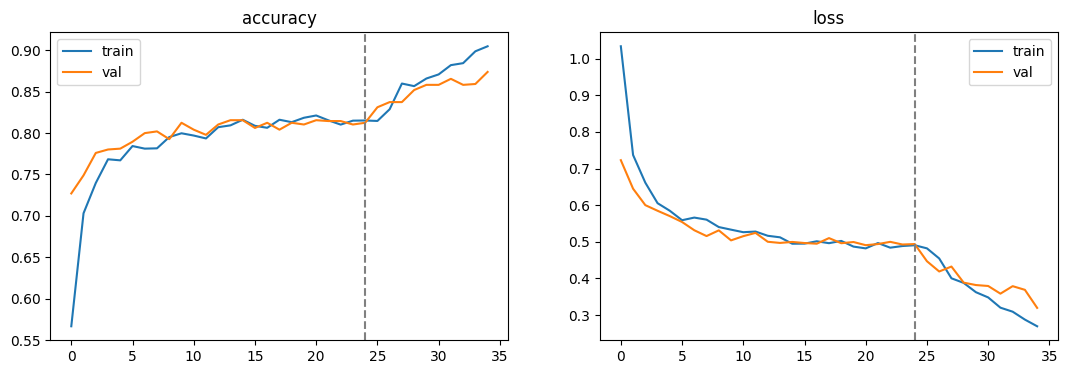

In [13]:
def stitch(k):
    return history.history[k] + history_ft.history[k]

acc, val_acc = stitch("accuracy"), stitch("val_accuracy")
loss, val_loss = stitch("loss"), stitch("val_loss")
split = len(history.history["accuracy"])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(acc, label="train"); ax[0].plot(val_acc, label="val")
ax[0].axvline(split - 1, ls="--", c="gray"); ax[0].set_title("accuracy"); ax[0].legend()
ax[1].plot(loss, label="train"); ax[1].plot(val_loss, label="val")
ax[1].axvline(split - 1, ls="--", c="gray"); ax[1].set_title("loss"); ax[1].legend()
plt.show()

## Evaluation on the held-out test set

Restoring the best weights saved across *both* training phases first, then scoring on the test
folder — which was never seen during training. Overall accuracy and loss, then the full precision /
recall / F1 breakdown per class, then the confusion matrix to see where it slips.

In [14]:
# restore the best weights saved across both phases, then score
model.load_weights(weights_path)

test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest accuracy: {test_acc:.3f}   test loss: {test_loss:.3f}")

y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_prob = model.predict(test_ds)
y_pred = y_prob.argmax(axis=1)

print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 153ms/step - accuracy: 0.8650 - loss: 0.4017

Test accuracy: 0.865   test loss: 0.402
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step
              precision    recall  f1-score   support

      defect      0.906     0.767     0.831       400
   longberry      0.905     0.930     0.917       400
    peaberry      0.869     0.895     0.882       400
     premium      0.792     0.868     0.828       400

    accuracy                          0.865      1600
   macro avg      0.868     0.865     0.865      1600
weighted avg      0.868     0.865     0.865      1600



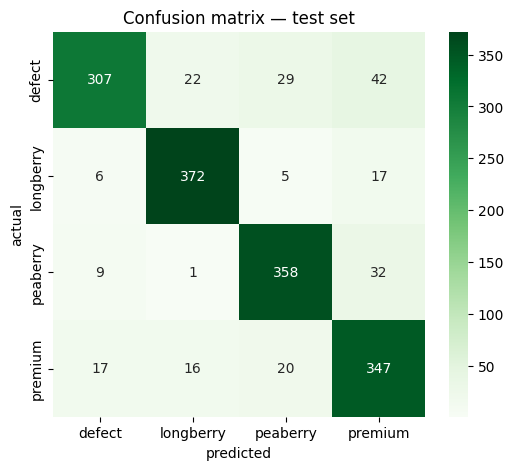

In [15]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("predicted"); plt.ylabel("actual"); plt.title("Confusion matrix — test set")
plt.show()

The classification report covers the four metrics the rubric wants — accuracy, plus per-class
precision, recall and F1 — and the loss came out of `evaluate` above. If the `defect` row is the
weakest, that lines up with what the mean-image plot hinted at earlier: defective beans are the most
visually varied, so they're the easiest to confuse with the rest.

## Single-image prediction

This is the function the deployment API will wrap: one image path in, predicted class and confidence
out. Keeping it self-contained so it drops straight into `src/prediction.py` with no rewrites.
Note there's no manual rescaling here — `preprocess_input` already lives inside the model.

In [16]:
def predict_image(path, model=model):
    img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.expand_dims(img, 0)
    prob = model.predict(img, verbose=0)[0]
    idx = int(prob.argmax())
    return {"class": class_names[idx], "confidence": round(float(prob[idx]), 4)}

# sanity check on one real test image
sample = str(next(Path(f"{DATA_DIR}/test/premium").glob("*.jpg")))
print(sample.split("/")[-1], "->", predict_image(sample))

1760.jpg -> {'class': 'peaberry', 'confidence': 0.6485}


## Saving the model

Native Keras format for the API to load. (`.h5` works too — the assignment accepts either — just
change the extension.) I also copy it to Drive so it survives the Colab session resetting.

In [17]:
import shutil
os.makedirs("models", exist_ok=True)
model.save("models/coffee_model.keras")
shutil.copy("models/coffee_model.keras", "/content/drive/MyDrive/coffee_model.keras")
print("saved -> models/coffee_model.keras  (and copied to Drive)")

saved -> models/coffee_model.keras  (and copied to Drive)


## Retraining

The pipeline has to retrain when new labelled beans show up — a new harvest, a new sorting batch.
The bit that matters for the rubric: retraining **loads the model we just trained and continues from
there**, it does not start from scratch. The existing knowledge stays; the new data gets folded in.

Two pieces below — a trigger that decides *whether* to retrain based on how many new images have
piled up, and the retrain routine itself. In the deployed app this exact logic sits behind the
upload counter and the "retrain" button.

In [ ]:
def should_retrain(new_data_dir, threshold=50):
    # trigger: retrain once enough new labelled images have accumulated
    n = len(list(Path(new_data_dir).rglob("*.jpg")))
    print(f"{n} new images waiting (threshold {threshold})")
    return n >= threshold


def retrain(new_data_dir, epochs=3):
    # load the model we already trained — THIS is the pretrained starting point
    current = tf.keras.models.load_model("models/coffee_model.keras")

    new_ds = tf.keras.utils.image_dataset_from_directory(
        new_data_dir,
        image_size=IMG_SIZE,
        batch_size=BATCH,
        class_names=class_names,   # never let Keras infer these. It derives
                                   # labels alphabetically from whichever
                                   # folders happen to exist, so an upload of
                                   # only defect/ and premium/ would map them
                                   # to indices 0 and 1 — and index 1 means
                                   # longberry to the model. Training would
                                   # then silently learn wrong labels.
    ).prefetch(AUTOTUNE)

    current.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    current.fit(new_ds, epochs=epochs)

    # version the output so the old model is never clobbered
    from datetime import datetime
    stamp = datetime.now().strftime("%Y%m%d_%H%M")
    out = f"models/coffee_model_{stamp}.keras"
    current.save(out)
    print("retrained model saved ->", out)
    return current


# In the demo, point this at the folder of freshly uploaded beans:
# if should_retrain("/content/new_uploads"):
#     retrain("/content/new_uploads")

## Next steps

Model file is saved — that's the artifact the rest of the pipeline is built around. From here:

- `src/preprocessing.py` — the dataset loading + augmentation from above
- `src/model.py` — `build`, `train`, and the fine-tuning routine
- `src/prediction.py` — the `predict_image` function
- FastAPI wrapping predict / upload / retrain / status
- Docker + Locust for the load test with different container counts

The `retrain` function here is the same one the API calls when new data comes in — so the notebook
and the deployed service stay in sync.